
# Лабораторная работа 4. Метод k-ближайших соседей (k-NN)

План работы:
1. Загрузать и проверить данные.
2. Провести предварительную обработку (пропуски, масштабирование).
3. Получить базовую статистику и визуализации.
4. Реализовать метод k-NN **вручную** (без sklearn).
5. Построить две модели с разными наборами признаков.
6. Оценить качество моделей при разных значениях `k` и построить матрицу ошибок.




## 1. Импорт библиотек


In [2]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from collections import Counter
import itertools

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = True

print("Импорт библиотек выполнен.")

Импорт библиотек выполнен.



## 2. Загрузка данных и первичный анализ

На этом шаге я:
- загружаю датасет;
- смотрим размер таблицы;
- выводим первые строки;
- проверяем типы столбцов.


In [3]:
data_path = "diabetes.csv"

df = pd.read_csv(data_path)
print("Размер датасета:", df.shape)
display(df.head())
#display(df)
df.info()

Размер датасета: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   Pedigree       768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB



## 3. Предварительная обработка данных

Нам необходимо произвести предварительную обработку данных, потому что алгоритмы, чувствительны к пропущенным и некорректным значениям,
а также в датасете в некоторых признаках есть пропуски(`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`).
Заполним пропуски **медианой** по столбцу.

Медиана возьмем, потому чот она устойчива к выбросам и хорошо подходит для числовых признаков.


In [4]:
print("Число пропусков до обработки:")
print(df.isna().sum())

cols_with_zero_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zero_missing:
    if col in df.columns:
        df[col] = df[col].replace(0, np.nan)

print("\nЧисло пропусков после замены нулей на NaN:")
print(df.isna().sum())

for col in df.columns:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\nЧисло пропусков после заполнения медианой:")
print(df.isna().sum())

Число пропусков до обработки:
Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Pedigree         0
Age              0
Outcome          0
dtype: int64

Число пропусков после замены нулей на NaN:
Pregnancies        0
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
Pedigree           0
Age                0
Outcome            0
dtype: int64

Число пропусков после заполнения медианой:
Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Pedigree         0
Age              0
Outcome          0
dtype: int64



## 4. Описательная статистика и визуализация


In [5]:
display(df.describe())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


По описательной статистике видно, что значения признаков имеют разный диапазон и разный разброс, что подтверждает необходимость последующего масштабирования данных. Некоторые признаки, такие как Insulin и SkinThickness, демонстрируют большой размах между минимумом и максимумом, что указывает на наличие выбросов и неоднородность распределения. Кроме того, медианные значения существенно отличаются от средних, что говорит о смещённых распределениях и возможном наличии экстремальных значений в данных.



Мы разделяем данные на матрицу признаков X и целевую переменную y, чтобы отделить входные данные от правильных ответов,
которые модель должна предсказывать. Это необходимо, чтобы алгоритм k-NN вычислял расстояния только по признакам и не использовал целевой столбец,
иначе произошла бы утечка информации и некорректное обучение.

Разделим таблицу на матрицу признаков `X` и целевой вектор `y`:

- X — все столбцы, кроме `Outcome`;
- y — столбец `Outcome`.


In [7]:
target_column = 'Outcome'
X = df.drop(columns=[target_column])
y = df[target_column]

features = X.columns
print("Число признаков:", len(features))
print("Список признаков:", list(features))

Число признаков: 8
Список признаков: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Pedigree', 'Age']



### 4.1. Гистограммы признаков


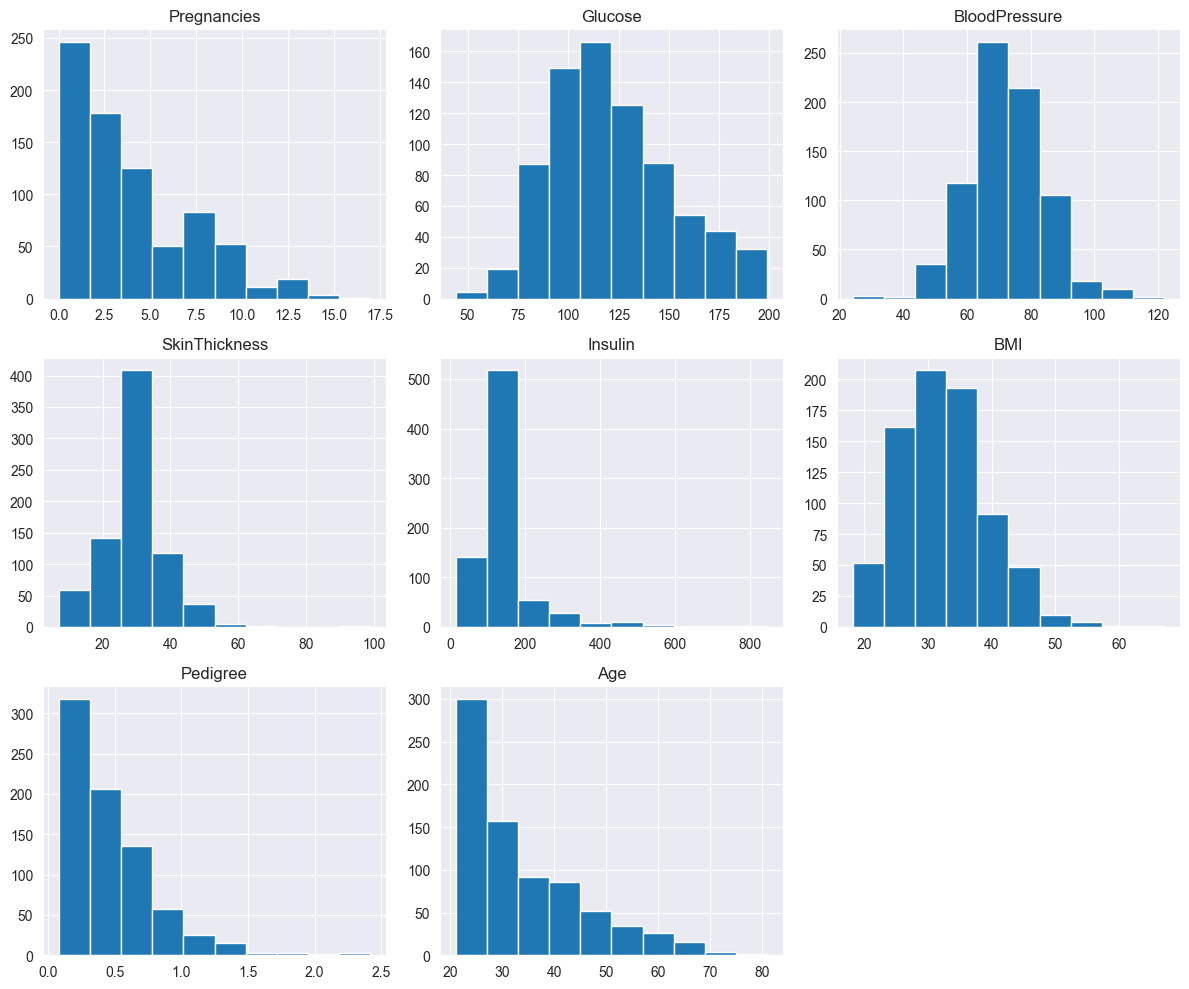

In [8]:
X.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()


### 4.2. 3D-визуализация трёх признаков

Выбираем три признака и отобразим точки в 3D-пространстве, раскрасив их по целевому классу `Outcome`.
Это даёт наглядное представление о разделимости классов в признаковом пространстве.


Три признака для 3D-графика: Pregnancies Glucose BloodPressure


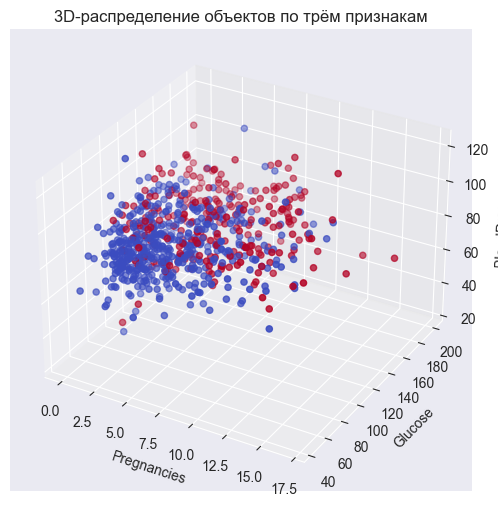

In [9]:
x_col, y_col, z_col = features[0], features[1], features[2]
print("Три признака для 3D-графика:", x_col, y_col, z_col)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X[x_col], X[y_col], X[z_col], c=y, cmap='coolwarm')
ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.set_zlabel(z_col)
plt.title("3D-распределение объектов по трём признакам")
plt.show()


## 5. Масштабирование признаков

Метод k-NN основан на **расстояниях** между объектами. Если один признак измеряется в диапазоне \([0, 1000]\), а другой в \([0, 1]\), то первый будет доминировать в расстоянии.

Чтобы все признаки были сопоставимы, применяем **стандартизацию**:

$$
z = \frac{x - \mu}{\sigma}
$$

где:

- $x$ — исходное значение признака
- $\mu$ — среднее значение признака
- $\sigma$ — стандартное отклонение

После стандартизации каждый признак имеет примерно нулевое среднее и единичное стандартное отклонение.



In [10]:
X_scaled = (X - X.mean()) / X.std()
display(X_scaled.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age
0,0.639530,0.865481,-0.031969,0.670206,-0.181423,0.166511,0.468187,1.425067
1,-0.844335,-1.204281,-0.527975,-0.012293,-0.181423,-0.851645,-0.364823,-0.190548
2,1.233077,2.015348,-0.693310,-0.012293,-0.181423,-1.331632,0.604004,-0.105515
3,-0.844335,-1.072868,-0.527975,-0.694792,-0.540290,-0.633469,-0.920163,-1.040871
4,-1.141108,0.504094,-2.677331,0.670206,0.316360,1.548294,5.481337,-0.020483


После стандартизации все признаки приведены к единому масштабу: их значения теперь выражены в отклонениях от среднего и находятся примерно в диапазоне от –3 до +3. Это подтверждает, что масштабирование выполнено корректно и ни один признак больше не доминирует по величине. Такая нормализация обеспечивает корректное вычисление расстояний в методе k-NN и улучшает качество классификации.


## 6. Разделение на обучающую и тестовую выборки

Для оценки качества модели нужно отделить часть данных, на которых мы не обучаемся, а только проверяем результат — это тестовая выборка.

Реализуем простую версию `train_test_split` вручную:

1. Перемешиваем индексы объектов.
2. Берём первые `test_size` процентов как тест.
3. Остальные — обучающая выборка.


In [11]:
def train_test_split_manual(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    n = len(X)
    indices = np.random.permutation(n)
    test_n = int(n * test_size)

    test_idx = indices[:test_n]
    train_idx = indices[test_n:]

    X_train = X.iloc[train_idx].values
    X_test = X.iloc[test_idx].values
    y_train = y.iloc[train_idx].values
    y_test = y.iloc[test_idx].values

    return X_train, X_test, y_train, y_test, train_idx, test_idx

X_train_full, X_test_full, y_train, y_test, train_idx, test_idx = train_test_split_manual(X_scaled, y)

print("Размер обучающей выборки:", X_train_full.shape)
print("Размер тестовой выборки:", X_test_full.shape)

Размер обучающей выборки: (615, 8)
Размер тестовой выборки: (153, 8)



## 7. Метод k-ближайших соседей (k-NN)

### Идея алгоритма

Алгоритм $k$-ближайших соседей относится к простым методам классификации.
Когда мы хотим определить класс нового объекта, мы смотрим на объекты из обучающей выборки, которые находятся ближе всего к нему.
Затем выбираем $k$ ближайших соседей и присваиваем объекту тот класс, который встречается среди них чаще всего.

### Метрика расстояния

Чтобы понять, какие объекты ближе друг к другу, мы используем евклидово расстояние между двумя объектами $\vec{x}$ и $\vec{y}$:

$$
\
d(\vec{x}, \vec{y}) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2},
\
$$

где $n$ — число признаков.

### Пошаговый алгоритм k-NN для одного объекта

1) Для нового объекта вычисляем расстояние до каждого объекта из обучающей выборки.
2) Сортируем обучающие объекты по расстоянию и выбираем $k$ наиболее близких.
3) Смотрим, какие классы встречаются среди этих $k$ соседей и сколько раз.
4) Класс, который встречается чаще других, назначается новому объекту.


In [12]:

def euclidean_distance(x1, x2):
    distance = 0
    for i in range(len(x1)):
        distance += (x1[i] - x2[i]) ** 2
    return math.sqrt(distance)



def knn_predict(X_train, y_train, X_test, k):
    predictions = []

    for x in X_test:
        distances = []
        for i in range(len(X_train)):
            d = euclidean_distance(X_train[i], x)
            distances.append((d, y_train[i]))
        distances.sort(key=lambda pair: pair[0])
        k_nearest = distances[:k]
        neighbor_labels = [label for (_, label) in k_nearest]
        most_common_label = max(set(neighbor_labels), key=neighbor_labels.count)
        predictions.append(most_common_label)

    return np.array(predictions)


print("Ручная реализация k-NN определена.")


Ручная реализация k-NN определена.



## 8. Две модели с разными наборами признаков

В этой части работы я строю две модели k-NN, каждая из которых использует свой набор признаков.
Это нужно для того, чтобы посмотреть, насколько выбор признаков влияет на итоговое качество классификации.

Согласно заданию, нужно построить две модели k-NN:

1. **Модель 1** — Здесь я случайным образом выбираю несколько признаков. Такой эксперимент показывает, сможет ли алгоритм работать хорошо, если признаки выбраны без предварительного анализа.
2. **Модель 2** — В этой модели я использую заранее определённый набор наиболее информативных признаков. Такой подход позволяет проверить, улучшится ли качество классификации, если признаки подобрать осмысленно.

Делаем мы это, чтобы понять как правильный выбор признаков дает преимущество при обуении модели.


In [13]:
all_features = list(X_scaled.columns)

# Модель 1
np.random.seed(42)
num_random_features = min(4, len(all_features))  # возьмем 4 признака
random_features = np.random.choice(all_features, size=num_random_features, replace=False)

# Модель 2
preferred_fixed_features = ['Glucose', 'BMI', 'Age', 'BloodPressure']
fixed_features = [f for f in preferred_fixed_features if f in all_features]
if len(fixed_features) == 0:
    fixed_features = all_features[:num_random_features]

print("Случайные признаки (Model 1):", random_features)
print("Фиксированные признаки (Model 2):", fixed_features)

X_random = X_scaled[random_features]
X_random_train = X_random.iloc[train_idx].values
X_random_test = X_random.iloc[test_idx].values

X_fixed = X_scaled[fixed_features]
X_fixed_train = X_fixed.iloc[train_idx].values
X_fixed_test = X_fixed.iloc[test_idx].values

Случайные признаки (Model 1): ['Glucose' 'BMI' 'Pregnancies' 'Age']
Фиксированные признаки (Model 2): ['Glucose', 'BMI', 'Age', 'BloodPressure']



## 9. Метрики качества и матрица ошибок

Для оценки качества работы модели используется матрица ошибок, которая показывает, насколько часто модель предсказывает классы правильно и какие типы ошибок допускает. Матрица имеет вид:

\
\begin{pmatrix}
TN & FP \\
FN & TP
\end{pmatrix}

где:
- **TP** (True Positive) — верно предсказанные объекты класса 1;
- **TN** (True Negative) — верно предсказанные объекты класса 0;
- **FP** (False Positive) — объекты класса 0, ошибочно отнесённые к 1;
- **FN** (False Negative) — объекты класса 1, ошибочно отнесённые к 0.

По матрице ошибок считаются метрики:

- **Accuracy** (доля верных ответов):
$$
\
\mathrm{Acc} = \frac{TP + TN}{TP + TN + FP + FN};
\
$$


- **Precision** (точность для положительного класса):

$$
\
\mathrm{Precision} = \frac{TP}{TP + FP};
\
$$


- **Recall** (полнота, чувствительность):

$$
\
\mathrm{Recall} = \frac{TP}{TP + FN};
\
$$

- **F1-мера** (гармоническое среднее точности и полноты):

$$
\
F1 = 2 \cdot \frac{\mathrm{Precision} \cdot \mathrm{Recall}}{\mathrm{Precision} + \mathrm{Recall}}.
\
$$

In [14]:
def confusion_matrix_binary(y_true, y_pred):
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    return np.array([[tn, fp],
                     [fn, tp]])


def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)


def precision_recall_f1(y_true, y_pred):
    cm = confusion_matrix_binary(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1


def plot_confusion_matrix(cm, classes=('0', '1'), title='Confusion matrix'):
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, [f"Pred {c}" for c in classes])
    plt.yticks(tick_marks, [f"True {c}" for c in classes])


    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


print("Функции метрик качества и визуализации матрицы ошибок определены.")


Функции метрик качества и визуализации матрицы ошибок определены.



## 10. Оценка моделей при разных значениях k

Метод k-NN чувствителен к выбору параметра
k — числа соседей, учитываемых при классификации. Разные значения
k могут приводить к разному качеству модели: при слишком малом
k алгоритм становится слишком «чувствительным» к шуму, а при слишком большом — может чрезмерно сглаживать различия между классами. Поэтому важно протестировать несколько вариантов
k и определить, какое значение обеспечивает наиболее стабильную и точную классификацию.

По заданию нужно протестировать несколько значений \(k\), например:
- \(k = 3\),
- \(k = 5\),
- \(k = 10\).

Для каждого \(k\) и для каждой модели (случайные признаки / фиксированные признаки) считаем:

- Accuracy,
- Precision,
- Recall,
- F1.


In [15]:
ks = [3, 5, 10]

results_random = []
results_fixed = []

for k in ks:

    y_pred_random = knn_predict(X_random_train, y_train, X_random_test, k)

    acc_r = accuracy_score(y_test, y_pred_random)
    pr_r, rc_r, f1_r = precision_recall_f1(y_test, y_pred_random)

    results_random.append((k, acc_r, pr_r, rc_r, f1_r))



    y_pred_fixed = knn_predict(X_fixed_train, y_train, X_fixed_test, k)
    acc_f = accuracy_score(y_test, y_pred_fixed)
    pr_f, rc_f, f1_f = precision_recall_f1(y_test, y_pred_fixed)

    results_fixed.append((k, acc_f, pr_f, rc_f, f1_f))


df_results_random = pd.DataFrame(
    results_random,
    columns=["k", "Accuracy", "Precision", "Recall", "F1"]
)

df_results_fixed = pd.DataFrame(
    results_fixed,
    columns=["k", "Accuracy", "Precision", "Recall", "F1"]
)


print("Результаты для модели 1 (случайные признаки):")
display(df_results_random)

print("Результаты для модели 2 (фиксированные признаки):")
display(df_results_fixed)


Результаты для модели 1 (случайные признаки):


,k,Accuracy,Precision,Recall,F1
0,3,0.745098,0.642857,0.654545,0.648649
1,5,0.764706,0.655738,0.727273,0.689655
2,10,0.790850,0.744681,0.636364,0.686275


Результаты для модели 2 (фиксированные признаки):


,k,Accuracy,Precision,Recall,F1
0,3,0.758170,0.655172,0.690909,0.672566
1,5,0.751634,0.639344,0.709091,0.672414
2,10,0.745098,0.660000,0.600000,0.628571


Модель со случайными признаками показала лучший результат при
k=10, тогда как модель с фиксированными признаками лучше работала при меньших значениях
k, особенно при
k=3. В целом качество обеих моделей меняется с увеличением
k.


## 11. Матрица ошибок для выбранного k

Для иллюстрации построим матрицу ошибок для одной из моделей и выбранного значения \(k\).


Матрица ошибок (k = 5 ):
[[76 22]
 [16 39]]


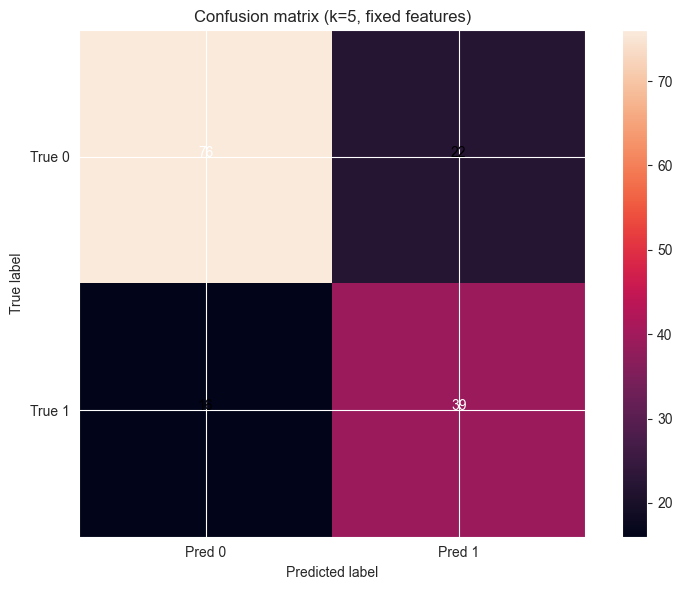

In [16]:
k_example = 5

y_pred_example = knn_predict(X_fixed_train, y_train, X_fixed_test, k_example)
cm_example = confusion_matrix_binary(y_test, y_pred_example)

print("Матрица ошибок (k =", k_example, "):")
print(cm_example)

plot_confusion_matrix(cm_example, classes=("0", "1"),
                      title=f"Confusion matrix (k={k_example}, fixed features)")

Матрица ошибок показывает, как модель распределяет правильные и неправильные предсказания между двумя классами. В данном случае модель корректно классифицировала 76 объектов класса 0 и 39 объектов класса 1, но ошиблась в 22 случаях для класса 0 и в 16 — для класса 1. Такой результат говорит о том, что модель лучше распознаёт отрицательный класс, чем положительный. В целом предсказания достаточно точные, но заметные ошибки по классу 1 указывают на необходимость выбора более подходящего
k или набора признаков.


## 12. Итоговые выводы

В ходе работы была реализована собственная версия алгоритма k-ближайших соседей и проведён анализ его поведения при разных наборах признаков и значениях параметра
k. Результаты показали, что выбор признаков существенно влияет на качество классификации: случайный набор дал более высокие метрики при большем
k, тогда как фиксированный набор признаков оказался более чувствительным к параметру и работал лучше при меньших значениях
k. Это может означать, что выбранный вручную набор признаков был не оптимален и не полностью отражал структуру данных, что привело к большему числу ошибок на тестовой выборке. Таким образом, для улучшения качества модели требуется либо тщательный отбор признаков, либо использование методов автоматической их оценки, а также дополнительный подбор оптимального значения
k.
